<a href="https://colab.research.google.com/github/bilal2343/machine-learning/blob/main/Hypertension_EDA_SIMPLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: EDA - Simple Version

**Hypertension Risk Prediction**

**Step 1: Load Libraries**

In [1]:
# Import tools we need
import pandas as pd  # For working with data tables
import numpy as np   # For working with numbers
import matplotlib.pyplot as plt  # For making charts
import seaborn as sns  # For making pretty charts

# Project settings
RANDOM_SEED = 42
TARGET_COLUMN = "Hypertension"  # What we want to predict

# Make charts look nice
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

print("✓ Libraries loaded")

✓ Libraries loaded


**Step 2: Load Data**

In [2]:
# Load the data file
df = pd.read_csv("hypertension_dataset.csv")

print(f"✓ Data loaded")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

✓ Data loaded
Number of rows: 174982
Number of columns: 23


**Step 3: Check Data Quality**

In [3]:
# Step 3a: Check for duplicate rows (same person appearing twice)
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Step 3b: Check for missing values (empty cells)
missing = df.isnull().sum()
total_missing = missing.sum()

if total_missing == 0:
    print("✓ No missing values")
else:
    print(f"\nMissing values found:")
    print(missing[missing > 0].to_string())

Duplicate rows: 0
✓ No missing values


**Step 4: Class Distribution (How many people have hypertension?)**

In [4]:
# Count people in each group
counts = df[TARGET_COLUMN].value_counts().sort_index()

print("Number of people in each group:")
for group, count in counts.items():
    print(f"  {group}: {count} people")

# Show as percentages
pcts = df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100
print("\nAs percentages:")
for group, pct in pcts.items():
    print(f"  {group}: {pct:.1f}%")

Number of people in each group:
  High: 125781 people
  Low: 49201 people

As percentages:
  High: 71.9%
  Low: 28.1%


**Step 5: Visualize Class Distribution**

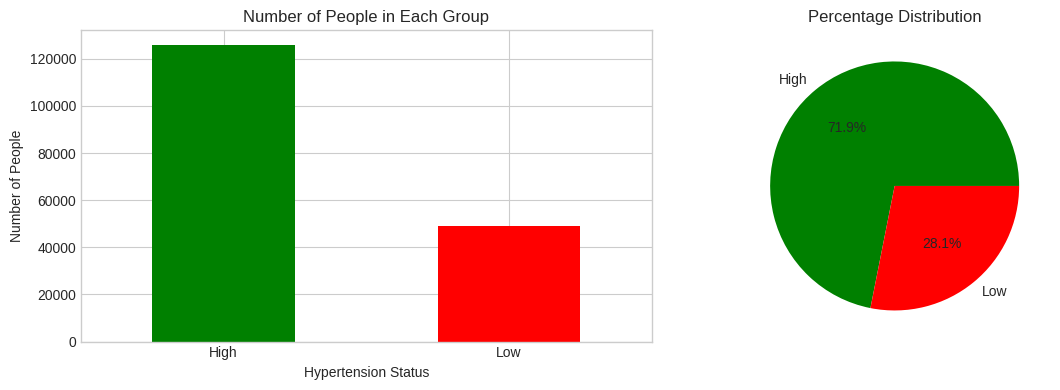

✓ Charts created


In [5]:
# Create two simple charts side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: Bar chart showing counts
counts.plot(kind='bar', ax=ax1, color=['green', 'red'])
ax1.set_title('Number of People in Each Group')
ax1.set_xlabel('Hypertension Status')
ax1.set_ylabel('Number of People')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Chart 2: Pie chart showing percentages
counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=['green', 'red'])
ax2.set_title('Percentage Distribution')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

print("✓ Charts created")

**Step 6: Look at Age Distribution**

Age Statistics:
  Youngest person: 18 years old
  Oldest person: 89 years old
  Average age: 53.5 years old


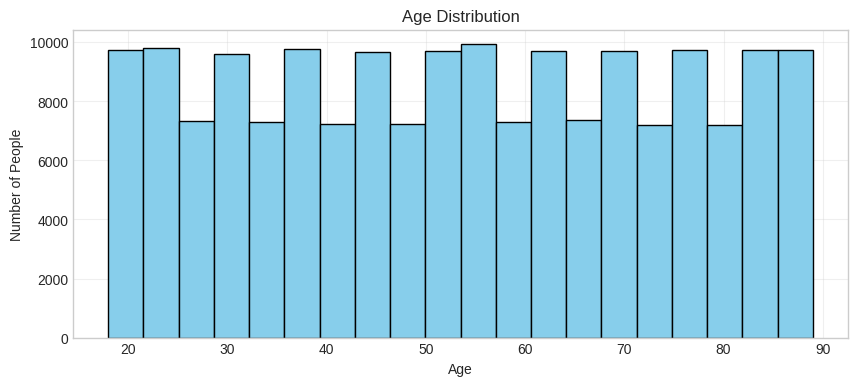

✓ Age chart created


In [6]:
# Show age statistics
print("Age Statistics:")
print(f"  Youngest person: {df['Age'].min()} years old")
print(f"  Oldest person: {df['Age'].max()} years old")
print(f"  Average age: {df['Age'].mean():.1f} years old")

# Create a simple histogram
plt.figure(figsize=(10, 4))
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.grid(True, alpha=0.3)
plt.show()

print("✓ Age chart created")

**Step 7: Look at Blood Pressure**

Blood Pressure Statistics:

Systolic (top number):
  Lowest: 90
  Highest: 179
  Average: 134.5

Diastolic (bottom number):
  Lowest: 60
  Highest: 119
  Average: 89.5


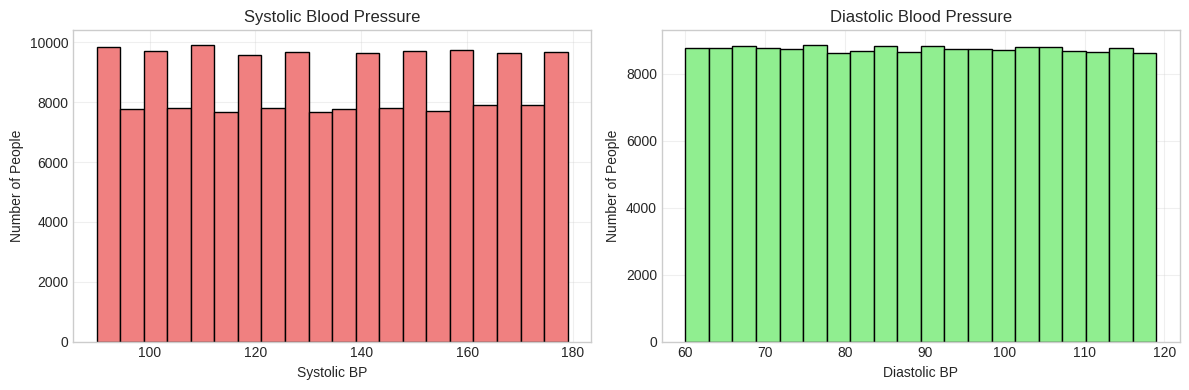

✓ Blood pressure charts created


In [7]:
# Show blood pressure statistics
print("Blood Pressure Statistics:")
print("\nSystolic (top number):")
print(f"  Lowest: {df['Systolic_BP'].min():.0f}")
print(f"  Highest: {df['Systolic_BP'].max():.0f}")
print(f"  Average: {df['Systolic_BP'].mean():.1f}")

print("\nDiastolic (bottom number):")
print(f"  Lowest: {df['Diastolic_BP'].min():.0f}")
print(f"  Highest: {df['Diastolic_BP'].max():.0f}")
print(f"  Average: {df['Diastolic_BP'].mean():.1f}")

# Create two side-by-side histograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(df['Systolic_BP'], bins=20, color='lightcoral', edgecolor='black')
ax1.set_title('Systolic Blood Pressure')
ax1.set_xlabel('Systolic BP')
ax1.set_ylabel('Number of People')
ax1.grid(True, alpha=0.3)

ax2.hist(df['Diastolic_BP'], bins=20, color='lightgreen', edgecolor='black')
ax2.set_title('Diastolic Blood Pressure')
ax2.set_xlabel('Diastolic BP')
ax2.set_ylabel('Number of People')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Blood pressure charts created")

**Step 8: Correlation Matrix (How features relate to each other)**

Calculating correlations for 14 numerical features
Features: ['Age', 'BMI', 'Cholesterol', 'Systolic_BP', 'Diastolic_BP', 'Alcohol_Intake', 'Stress_Level', 'Salt_Intake', 'Sleep_Duration', 'Heart_Rate', 'LDL', 'HDL', 'Triglycerides', 'Glucose']



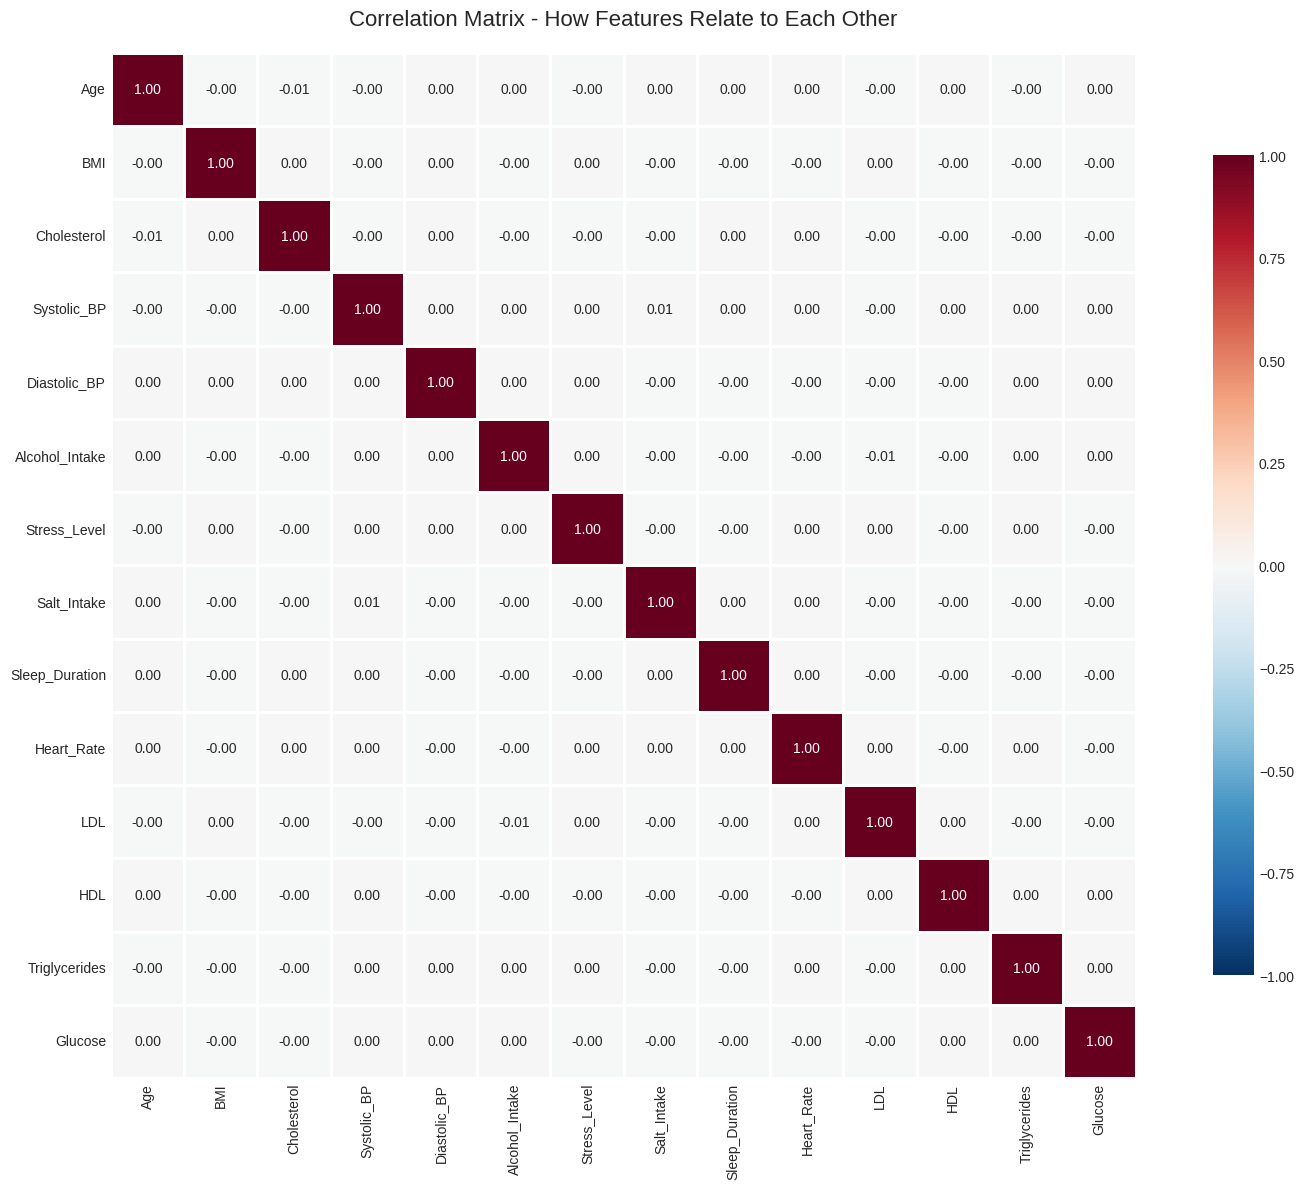


✓ Correlation matrix created

How to read this chart:
  🔴 Red = Positive correlation (both increase together)
  🔵 Blue = Negative correlation (one increases, other decreases)
  ⚪ White = No correlation (not related)

  Examples of strong correlations to look for:
  - Values close to +1.0 or -1.0 = very strong relationship
  - Values around ±0.5 to ±0.7 = moderate relationship
  - Values close to 0 = weak or no relationship


In [8]:
# Step 8a: Select only numerical columns for correlation
# (Correlation only works with numbers, not text)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Calculating correlations for {len(numerical_cols)} numerical features")
print(f"Features: {numerical_cols}\n")

# Step 8b: Calculate correlation (how features relate to each other)
# Values close to 1 = strong positive relationship
# Values close to -1 = strong negative relationship
# Values close to 0 = no relationship
correlation = df[numerical_cols].corr()

# Step 8c: Create a heatmap (color chart) to visualize correlations
plt.figure(figsize=(16, 12))
sns.heatmap(correlation,
            annot=True,  # Show numbers on the chart
            fmt='.2f',   # Show 2 decimal places
            cmap='RdBu_r',  # Red-Blue reversed colors (red=positive, blue=negative)
            center=0,    # Center the color scale at 0
            square=True,  # Make cells square-shaped
            linewidths=1,  # Add lines between cells
            cbar_kws={"shrink": 0.8},  # Make color bar smaller
            vmin=-1, vmax=1)  # Set scale from -1 to +1

plt.title('Correlation Matrix - How Features Relate to Each Other', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print("\n✓ Correlation matrix created")
print("\nHow to read this chart:")
print("  🔴 Red = Positive correlation (both increase together)")
print("  🔵 Blue = Negative correlation (one increases, other decreases)")
print("  ⚪ White = No correlation (not related)")
print("\n  Examples of strong correlations to look for:")
print("  - Values close to +1.0 or -1.0 = very strong relationship")
print("  - Values around ±0.5 to ±0.7 = moderate relationship")
print("  - Values close to 0 = weak or no relationship")

**Step 8b: Find Strongest Correlations**

In [9]:
# Find the strongest correlations (excluding the diagonal which is always 1.0)
print("Top 10 Strongest Correlations:")
print("="*70)

# Get absolute values and remove diagonal
corr_pairs = correlation.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1]  # Remove diagonal (perfect self-correlation)
corr_pairs = corr_pairs.sort_values(ascending=False)

# Show top 10 unique pairs
seen = set()
count = 0
for (var1, var2), value in corr_pairs.items():
    pair = tuple(sorted([var1, var2]))
    if pair not in seen:
        seen.add(pair)
        actual_corr = correlation.loc[var1, var2]
        direction = "positive" if actual_corr > 0 else "negative"
        print(f"{count+1}. {var1} ↔ {var2}")
        print(f"   Correlation: {actual_corr:.3f} ({direction})")
        count += 1
        if count >= 10:
            break

print("\n" + "="*70)
print("NOTE: Even these 'strongest' correlations are weak.")
print("This is EXPECTED and GOOD for our analysis!")
print("="*70)

Top 10 Strongest Correlations:
1. Age ↔ Cholesterol
   Correlation: -0.006 (negative)
2. Systolic_BP ↔ Salt_Intake
   Correlation: 0.005 (positive)
3. Alcohol_Intake ↔ LDL
   Correlation: -0.005 (negative)
4. Salt_Intake ↔ HDL
   Correlation: -0.005 (negative)
5. Triglycerides ↔ LDL
   Correlation: -0.005 (negative)
6. Glucose ↔ Age
   Correlation: 0.004 (positive)
7. Alcohol_Intake ↔ Triglycerides
   Correlation: 0.004 (positive)
8. Glucose ↔ Stress_Level
   Correlation: -0.004 (negative)
9. Salt_Intake ↔ Alcohol_Intake
   Correlation: -0.004 (negative)
10. Age ↔ Stress_Level
   Correlation: -0.004 (negative)

NOTE: Even these 'strongest' correlations are weak.
This is EXPECTED and GOOD for our analysis!


**Step 9: Summary Statistics**

In [10]:
# Show summary of all numerical columns
print("Summary of Numerical Data:")
print("="*60)
print(df.describe().to_string())
print("="*60)
print("\nNote: This shows count, mean (average), std (spread), min, max, etc.")

Summary of Numerical Data:
                 Age            BMI    Cholesterol    Systolic_BP   Diastolic_BP  Alcohol_Intake   Stress_Level    Salt_Intake  Sleep_Duration     Heart_Rate            LDL            HDL  Triglycerides        Glucose
count  174982.000000  174982.000000  174982.000000  174982.000000  174982.000000   174982.000000  174982.000000  174982.000000   174982.000000  174982.000000  174982.000000  174982.000000  174982.000000  174982.000000
mean       53.493319      27.494672     224.539335     134.505229      89.450315       14.991069       5.013041       8.482757        6.996468      74.495085     129.528271      64.573105     149.569836     134.488187
std        20.786353       7.213866      43.361589      26.019268      17.310789        8.652624       2.582341       3.750074        1.730731      14.438573      34.635795      20.190666      57.765006      37.526882
min        18.000000      15.000000     150.000000      90.000000      60.000000        0.000000     

**Step 10: See What Features Look Like**

In [11]:
# Show first 10 rows to understand the data
print("First 10 rows of data:")
print("="*80)
df.head(10)

First 10 rows of data:


,Country,Age,BMI,Cholesterol,Systolic_BP,Diastolic_BP,Smoking_Status,Alcohol_Intake,Physical_Activity_Level,Family_History,...,Sleep_Duration,Heart_Rate,LDL,HDL,Triglycerides,Glucose,Gender,Education_Level,Employment_Status,Hypertension
0,UK,58,29.5,230,160,79,Never,27.9,Low,Yes,...,6.1,80,100,75,72,179,Female,Primary,Unemployed,High
1,Spain,34,36.2,201,120,84,Never,27.5,High,Yes,...,9.8,56,77,47,90,113,Male,Secondary,Unemployed,High
2,Indonesia,73,18.2,173,156,60,Current,1.8,High,Yes,...,5.2,75,162,56,81,101,Male,Primary,Employed,Low
3,Canada,60,20.3,183,122,94,Never,11.6,Moderate,Yes,...,7.5,71,164,93,94,199,Female,Secondary,Retired,High
4,France,73,21.8,296,91,97,Never,29.1,Moderate,Yes,...,5.0,52,108,74,226,157,Female,Primary,Employed,High
5,UK,44,31.5,293,158,118,Former,20.3,Moderate,No,...,8.1,98,81,69,181,85,Male,Tertiary,Employed,High
6,South Korea,88,30.9,263,118,62,Current,8.6,Low,Yes,...,4.0,88,114,52,139,194,Male,Secondary,Employed,Low
7,Canada,25,18.1,151,175,101,Never,16.6,Low,Yes,...,5.8,99,154,34,132,193,Female,Secondary,Employed,High
8,Canada,89,19.0,198,102,104,Former,10.5,Low,Yes,...,6.6,56,157,81,145,161,Female,Primary,Retired,Low
9,Brazil,33,39.1,268,168,98,Current,20.7,Moderate,No,...,8.0,76,89,37,223,164,Male,Primary,Retired,High
